# exp_002 — Quantization with llama.cpp GGUF

Load measured summaries and a resolved artifact manifest. The notebook does not run the benchmark or invent missing measurements.

Capability outcomes and systems costs are reported in separate tables. The speed fields are stream-derived proxies; native prefill/decode counters are unavailable for this binding.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'src').is_dir() and (candidate / 'experiments').is_dir()
)
sys.path.insert(0, str(ROOT / 'src'))
from llm_lab.analysis.quantization import recommend_baseline, tradeoff_rows
from llm_lab.quantization import QuantizationManifest

RESULTS_DIR = ROOT / 'experiments/exp_002-quantization_llama_cpp_gguf/results'
SUMMARY_PATH = RESULTS_DIR / 'processed/summary.csv'
MANIFEST_PATH = RESULTS_DIR / 'manifest.json'
if not SUMMARY_PATH.is_file():
    raise FileNotFoundError(f'measured summary is required: {SUMMARY_PATH}')
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(f'resolved manifest is required: {MANIFEST_PATH}')

manifest = QuantizationManifest.from_record(json.loads(MANIFEST_PATH.read_text()))
summaries = pd.read_csv(SUMMARY_PATH)
EXPECTED_SCORER = 'calibrated.v1'
if 'scorer_version' not in summaries.columns:
    raise ValueError('summary is missing scorer_version; legacy summaries are not valid for this notebook')
scorer_versions = set(summaries['scorer_version'].dropna().astype(str))
if scorer_versions != {EXPECTED_SCORER}:
    raise ValueError(f'summary scorer policy must be {EXPECTED_SCORER!r}; found {sorted(scorer_versions)}')
required_columns = {
    'condition_id', 'attempted_n', 'scored_n', 'correct_n', 'failure_n',
    'scored_accuracy', 'end_to_end_success', 'failure_rate',
    'median_stream_ttft_s',
    'median_prompt_throughput_proxy_tok_s',
    'median_post_first_chunk_output_tok_s',
    'median_peak_memory_bytes',
}
missing_columns = required_columns - set(summaries.columns)
if missing_columns:
    raise ValueError(f'summary is missing required columns: {sorted(missing_columns)}')

rows = tradeoff_rows(summaries.to_dict('records'), manifest)
frame = pd.DataFrame(rows)
capability_frame = frame[[
    'condition_id', 'scored_accuracy', 'end_to_end_success', 'failure_rate'
]].sort_values('condition_id')
systems_cost_frame = frame[[
    'condition_id', 'artifact_size_bytes', 'median_peak_memory_bytes',
    'median_stream_ttft_s', 'median_prompt_throughput_proxy_tok_s',
    'median_post_first_chunk_output_tok_s'
]].sort_values('condition_id')
capability_frame, systems_cost_frame

,condition_id,label,format,quantization_type,bits,runtime_kernel,artifact_uri,artifact_sha256,artifact_size_bytes,attempted_n,...,correct_n,failure_n,scored_accuracy,end_to_end_success,failure_rate,accuracy,median_stream_ttft_s,median_prompt_throughput_proxy_tok_s,median_post_first_chunk_output_tok_s,median_peak_memory_bytes
0,q8_0,Q8_0,GGUF,Q8_0,8,ggml,artifacts/q8_0.gguf,6cb70620c7811dce01e1a622fe0a4f9ac445e31c569640...,29047084256,30,...,10.0,0,0.333333,0.333333,0.0,0.333333,198.641129,107.751810,7.565847,3.072627e+10
1,q6_k,Q6_K,GGUF,Q6_K,6,ggml,artifacts/q6_k.gguf,1f6a8e5d44e8cea0927908fd701348906de3e705564611...,22430999776,30,...,10.0,0,0.333333,0.333333,0.0,0.333333,210.831649,101.162613,9.193767,3.076463e+10
2,q5_k_m,Q5_K_M,GGUF,Q5_K_M,5,ggml,artifacts/q5_k_m.gguf,48fbca2bc04f59297981aabd0dbbe5e51efa8df13595e7...,19535701216,30,...,10.0,0,0.333333,0.333333,0.0,0.333333,226.006455,94.291189,9.403388,3.076463e+10
3,q4_k_m,Q4_K_M,GGUF,Q4_K_M,4,ggml,artifacts/q4_k_m.gguf,8b259e30f860c924fa1fd12d459343e8c2520eb12741f9...,16810714336,30,...,10.0,0,0.333333,0.333333,0.0,0.333333,206.192177,101.905525,11.040073,3.076463e+10


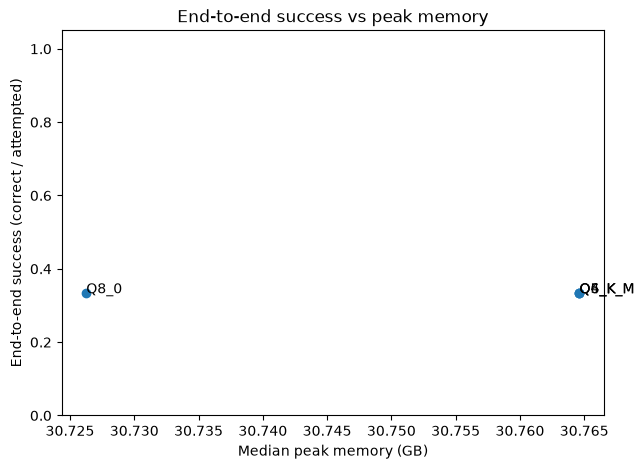

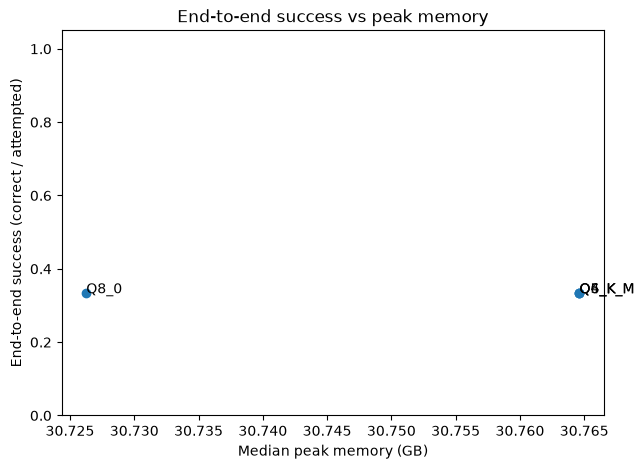

In [2]:
def accuracy_vs_memory(frame: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(frame['median_peak_memory_bytes'] / 1e9, frame['end_to_end_success'])
    for _, row in frame.iterrows():
        ax.annotate(row['label'], (row['median_peak_memory_bytes'] / 1e9, row['end_to_end_success']))
    ax.set_xlabel('Median peak memory (GB)')
    ax.set_ylabel('End-to-end success (correct / attempted)')
    ax.set_title('End-to-end success vs peak memory')
    ax.set_ylim(0, 1.05)
    return fig

RESULTS_DIR.joinpath('figures').mkdir(parents=True, exist_ok=True)
accuracy_figure = accuracy_vs_memory(frame)
accuracy_figure.savefig(RESULTS_DIR / 'figures' / 'accuracy-vs-memory.png', dpi=160, bbox_inches='tight')
accuracy_figure

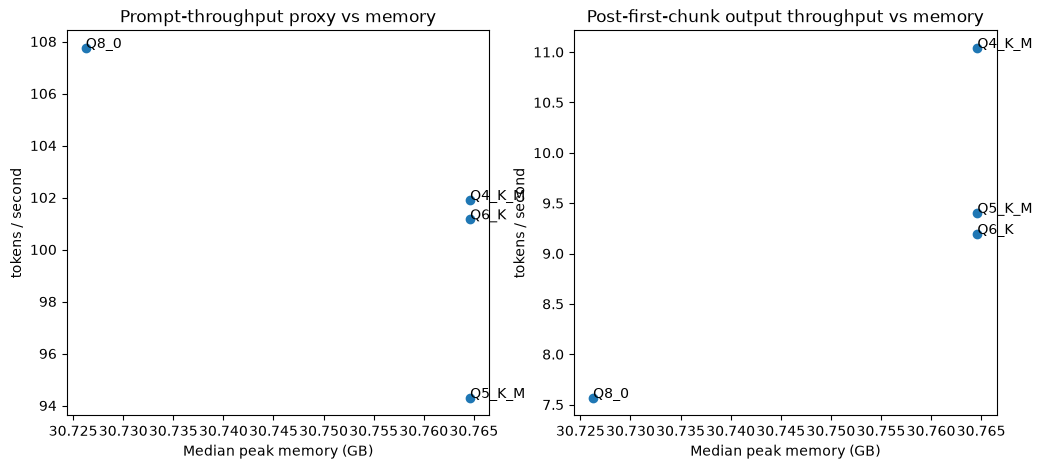

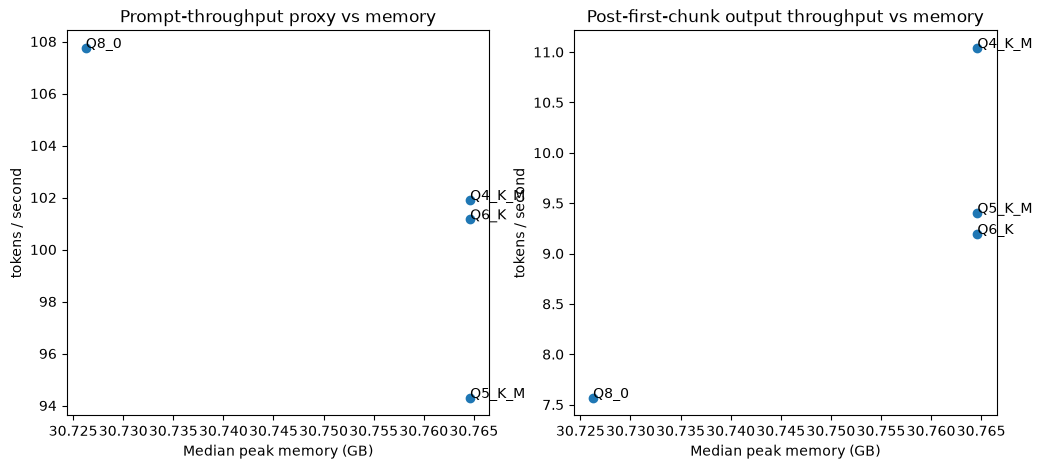

In [3]:
def speed_vs_memory(frame: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
    x = frame['median_peak_memory_bytes'] / 1e9
    axes[0].scatter(x, frame['median_prompt_throughput_proxy_tok_s'])
    axes[1].scatter(x, frame['median_post_first_chunk_output_tok_s'])
    for axis, column in zip(axes, ('median_prompt_throughput_proxy_tok_s', 'median_post_first_chunk_output_tok_s')):
        for _, row in frame.iterrows():
            axis.annotate(row['label'], (row['median_peak_memory_bytes'] / 1e9, row[column]))
        axis.set_xlabel('Median peak memory (GB)')
        axis.set_ylabel('tokens / second')
    axes[0].set_title('Prompt-throughput proxy vs memory')
    axes[1].set_title('Post-first-chunk output throughput vs memory')
    return fig

speed_figure = speed_vs_memory(frame)
speed_figure.savefig(RESULTS_DIR / 'figures' / 'speed-vs-memory.png', dpi=160, bbox_inches='tight')
speed_figure

In [4]:
recommendation = recommend_baseline(rows, accuracy_tolerance=0.02)
print({
    'recommended_condition': recommendation['condition_id'],
    'recommended_label': recommendation['label'],
    'scored_accuracy': recommendation['scored_accuracy'],
    'end_to_end_success': recommendation['end_to_end_success'],
    'failure_rate': recommendation['failure_rate'],
    'artifact_size_bytes': recommendation['artifact_size_bytes'],
    'best_end_to_end_success': recommendation['best_end_to_end_success'],
    'accuracy_tolerance': recommendation['accuracy_tolerance'],
})

{'recommended_condition': 'q4_k_m', 'recommended_label': 'Q4_K_M', 'scored_accuracy': 0.3333333333333333, 'end_to_end_success': 0.3333333333333333, 'failure_rate': 0.0, 'artifact_size_bytes': 16810714336, 'best_end_to_end_success': 0.3333333333333333, 'accuracy_tolerance': 0.02}
